In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from tensorflow.keras.datasets import mnist

# Automatically downloads and loads
(x_train, y_train), (x_test, y_test) = mnist.load_data()


#Automatically downloads and loads the Fashion MNIST dataset
'''from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

'''

'from tensorflow.keras.datasets import fashion_mnist\n\n(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()\n\n'

In [4]:
print('x_train shape: ',x_train.shape)
print('x_test shape: ',x_test.shape)
print('y_train shape: ',y_train.shape)
print('y_test shape: ',y_test.shape)

x_train shape:  (60000, 28, 28)
x_test shape:  (10000, 28, 28)
y_train shape:  (60000,)
y_test shape:  (10000,)


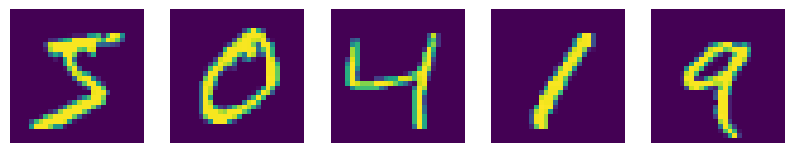

In [5]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i])#, cmap='gray')
    plt.axis('off')
#plt.tight_layout()
plt.show()


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model = RandomForestClassifier()

In [7]:
# 3. Flatten the images for model training
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

In [8]:
# 4. Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train_flat, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# 5. Predict on test data
y_pred = model.predict(x_test_flat)

In [10]:
# 6. Evaluate Accuracy
acc = accuracy_score(y_test, y_pred)
print("✅ Test Accuracy:", acc)

✅ Test Accuracy: 0.9705


In [11]:
# 7. Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



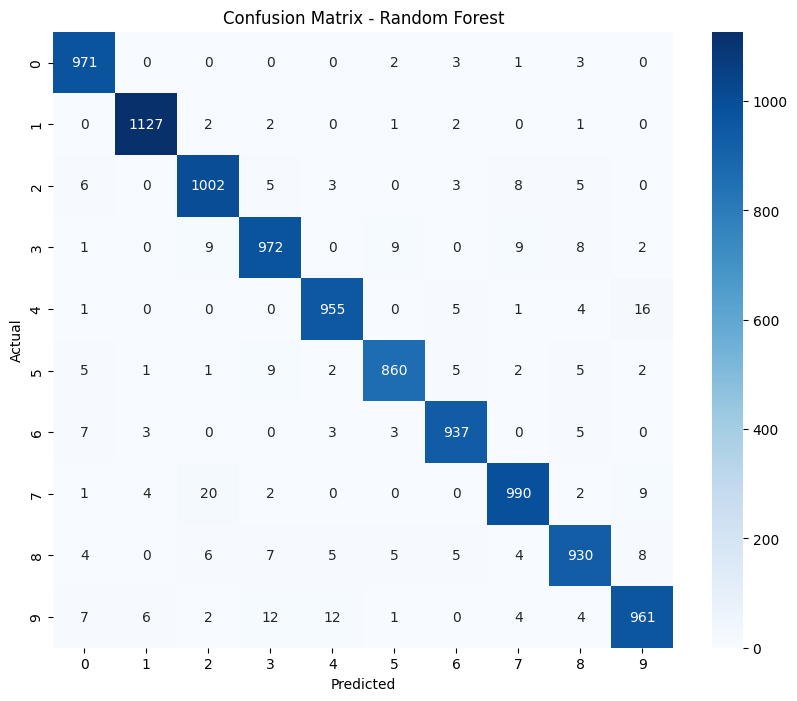

In [12]:
# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

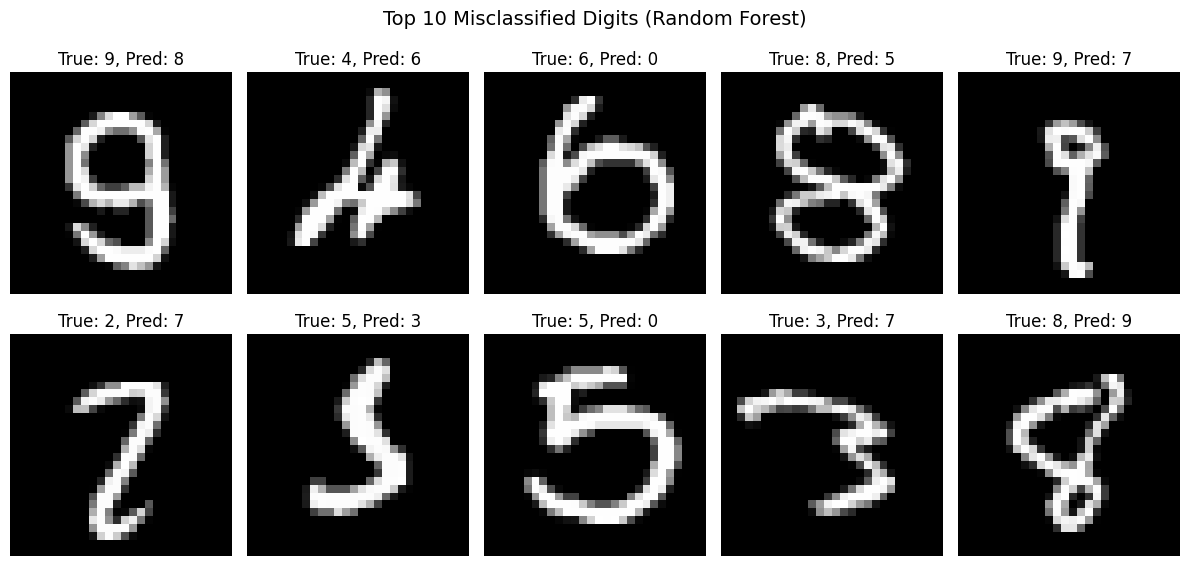

In [13]:


# 9. Visualize Misclassified Digits
misclassified_idx = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis('off')
plt.suptitle("Top 10 Misclassified Digits (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [15]:
# 4. Scale features (important for SGD)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

In [16]:
# 5. Train SGDClassifier with hinge loss (Linear SVM)
sgd = SGDClassifier(loss='hinge', max_iter=5, tol=1e-3, random_state=42)
sgd.fit(x_train_scaled, y_train)


c:\Users\ASC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDClassifier(max_iter=5, random_state=42)

In [17]:
# 6. Predict on test set
y_pred = sgd.predict(x_test_scaled)


In [18]:
# 7. Evaluate accuracy
acc = accuracy_score(y_test, y_pred)
print("✅ SGDClassifier Accuracy:", acc)


✅ SGDClassifier Accuracy: 0.9137


In [19]:
# 8. Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.97      0.97      1135
           2       0.93      0.88      0.90      1032
           3       0.89      0.90      0.89      1010
           4       0.92      0.92      0.92       982
           5       0.87      0.84      0.86       892
           6       0.92      0.94      0.93       958
           7       0.94      0.92      0.93      1028
           8       0.85      0.88      0.86       974
           9       0.89      0.90      0.89      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



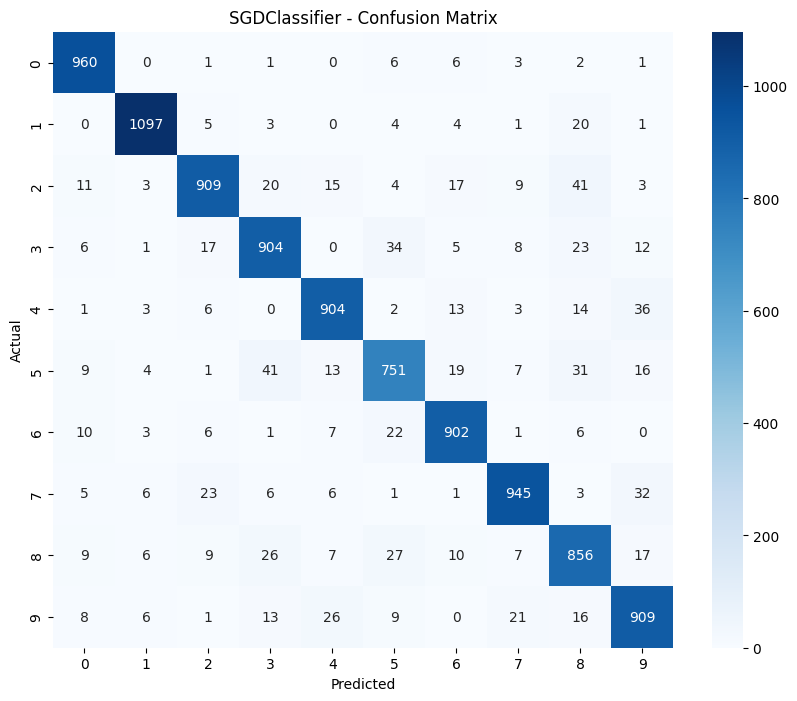

In [20]:
# 9. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SGDClassifier - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

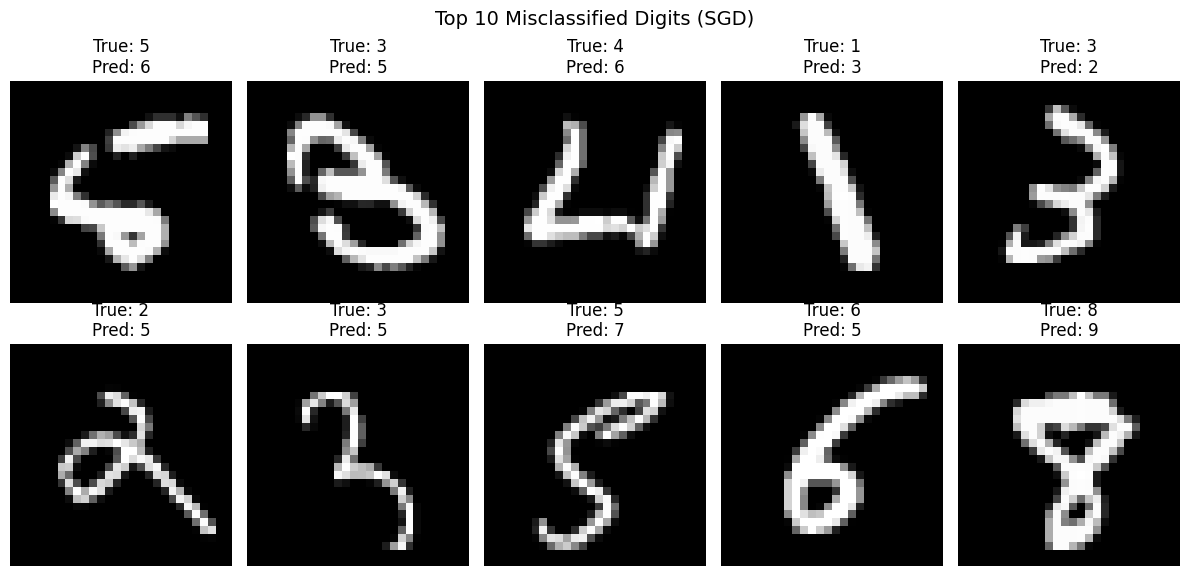

In [21]:

# 10. Visualize Misclassified Digits
wrong_idx = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(wrong_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.suptitle("Top 10 Misclassified Digits (SGD)", fontsize=14)
plt.tight_layout()
plt.show()


# Exercise 1

In [22]:
from tensorflow.keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

# Normalize (optional but improves accuracy)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

# Grid search for best hyperparameters
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(x_train_scaled[:10000], y_train[:10000])  # Use subset to speed up

# Best model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)

# Accuracy
print("✅ Accuracy with best KNN:", accuracy_score(y_test, y_pred))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
✅ Accuracy with best KNN: 0.9157


# Exercise 2: Image Shifting (Data Augmentation)

In [23]:
from scipy.ndimage import shift
import numpy as np

def shift_image(img, dx, dy):
    return shift(img.reshape(28, 28), [dy, dx], cval=0).reshape(784)

# Expand training set with shifted versions
X_train_aug = [x_train_flat[i] for i in range(len(x_train_flat))]
y_train_aug = [y_train[i] for i in range(len(y_train))]

for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Left, right, up, down
    for i in range(len(x_train_flat)):
        new_img = shift_image(x_train_flat[i], dx, dy)
        X_train_aug.append(new_img)
        y_train_aug.append(y_train[i])

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

# Train SGD on augmented data
X_train_aug_scaled = scaler.fit_transform(X_train_aug)
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='hinge', max_iter=10, tol=1e-3, random_state=42)
sgd.fit(X_train_aug_scaled, y_train_aug)
y_pred_aug = sgd.predict(x_test_scaled)

print("✅ Accuracy After Data Augmentation:", accuracy_score(y_test, y_pred_aug))


✅ Accuracy After Data Augmentation: 0.9059


c:\Users\ASC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


# Exercise 3: Titanic Dataset (Kaggle-based)

In [30]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

df = sns.load_dataset('titanic')  # Update path accordingly
df.head()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'].fillna('S', inplace=True)
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['alive']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("✅ Titanic Accuracy:", model.score(X_test, y_test))
print("📋 Titanic Classification Report:")
print(classification_report(y_test, model.predict(X_test)))


C:\Users\ASC\AppData\Local\Temp\ipykernel_20112\2814646768.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna('S', inplace=True)


✅ Titanic Accuracy: 0.8100558659217877
📋 Titanic Classification Report:
              precision    recall  f1-score   support

          no       0.83      0.86      0.84       105
         yes       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Exercise 4: Spam Classifier (Text Classification)

In [34]:
import os
import email
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

def load_emails_from_dir(directory):
    emails = []
    for filename in os.listdir(directory):
        with open(os.path.join(directory, filename), 'r', encoding='latin1') as f:
            msg = email.message_from_file(f)
            body = ''
            if msg.is_multipart():
                for part in msg.walk():
                    if part.get_content_type() == 'text/plain':
                        body += part.get_payload()
            else:
                body = msg.get_payload()
            emails.append(body)
    return emails

spam = load_emails_from_dir('spam')
ham = load_emails_from_dir('ham')

X = spam + ham
y = [1]*len(spam) + [0]*len(ham)

# Convert to feature vectors
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Spam Classifier Report:")
print(classification_report(y_test, y_pred))


✅ Spam Classifier Report:
              precision    recall  f1-score   support

           0       0.81      0.60      0.69        43
           1       0.86      0.94      0.90       108

    accuracy                           0.85       151
   macro avg       0.83      0.77      0.80       151
weighted avg       0.84      0.85      0.84       151

